# Домашняя работа 5: Сегментация

Работать будем с датасетом The Oxford-IIIT Pet Dataset: https://www.kaggle.com/datasets/devdgohil/the-oxfordiiit-pet-dataset/data.

План домашнего задания:
1. Напишем класс датасета для этих данных и Exploratory Data Analysis (EDA) — анализ датасета.
2. Посмотрим ground truth — сегментационные маски, улучшим их с помощью SAM.
3. Вспомним про U-Net из базы и улучшим его несколькими архитектурными нововведениями.
4. Построим пайплайн тренировки и обучим «улучшенный» U-Net на датасете.

Импортируем все необходимые библиотеки.

In [ ]:
import os
import random
import math
from collections import Counter
from typing import Callable, Optional, Union, Any
import xml.etree.ElementTree as ET

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision as tv
import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
from albumentations.pytorch import ToTensorV2
from torchinfo import summary
from tqdm import tqdm
from segment_anything import sam_model_registry, SamPredictor

## Часть 1: Датасет

Традиционно начнём домашнее задание с работы над датасетом. В данной части имплементируем класс `PetDataset` для работы с ним в дальнейшем, а также проведём простой EDA.

In [ ]:
data_root = ... # путь до папки с данными

Реализуйте класс `PetDataset`, он должен удовлетворять следующим требованиям:
1. Если параметр `train = True`, то используется trainval-часть, если нет, то test.
2. Атрибут `self.image_names` содержит названия всех изображений из нужной выборки.
3. Атрибут `self.image_classes` содержит метку класса для изображения (1 — для кошек, 2 — для собак), и его индексы соответствуют атрибуту выше.
4. Метод `__getitem__` возвращает пару из изображения и маски.
5. Маска изображения должна иметь всего два уникальных значения — 0 для бэкграунда и 1 или 2 для соответствующего животного, поэтому если `mask_folder = trimaps`, то объедините классы 1 и 3 из оригинальных масок.
6. Аугментации должны применяться одинаково как на картинку, так и на её маску, в случаях когда это необходимо (например, в геометрических преобразованиях).
7. Папка, соответствующая `mask_folder`, должна лежать в annotations внутри data_root.

**Внимание**: добавлять/убирать какие-либо семплы нельзя, иначе вы можете получить неправильные ответы в EDA-части!

Совет: **внимательно** почитайте все txt и readme в annotations — это может сильно облегчить вам жизнь :)

In [ ]:
class PetDataset(torch.utils.data.Dataset):
    def __init__(self, data_root: str, mask_folder: str = "trimaps", train: bool = True, transform: Optional[Callable] = None):
        super().__init__()

        ...

    def __len__(self) -> int:
        return len(self.image_names)

    def __getitem__(self, idx: int) -> tuple[Union[np.ndarray, torch.Tensor], Union[np.ndarray, torch.Tensor]]:
        ...

        return image, mask

In [ ]:
dataset = PetDataset(data_root)

Отлично, теперь можем работать с датасетом. Загрузите класс PetDataset в LMS на проверку.

Следующим этапом проведём небольшой EDA, постараемся ответить на три вопроса по **тренировочной** части датасета:
1. Кого больше — кошек или собак? В LMS отправьте «1» (без кавычек), если больше кошек, или «2», если больше собак.
2. Сколько всего пород у кошек и у собак? Ответ отправьте в LMS в формате «число_пород_кошек число_пород_собак».
3. Какое название и количество семплов у самой редкой породы? Ответ отправьте в LMS в формате «порода число». **Внимание**: указывайте название породы в точном соответствии с названием пород у файлов, т. е. условно если файл называется «Animal_Breed_1337», то порода в этом случае — «Animal_Breed», а не «Animal Breed» или «animalbreed».

In [ ]:
# Ваше решение
...

Ellipsis

Замечательно, разобрались с датасетом и немного ознакомились с его контентом. Теперь попробуем на нём SAM.

## Часть 2: Сегментация с помощью SAM

Посмотрим на несколько произвольных семплов из датасета глазами.

In [ ]:
# Вспомогательный код для визуализации
def plot_images(images: Union[list[np.ndarray], np.ndarray],
                titles: Optional[list] = None,
                figsize: tuple[int, int] = (12, 8),
                n_rows: Optional[int] = None,
                n_cols: Optional[int] = None) -> None:
    n_images = len(images)

    rows = n_rows if n_rows else math.ceil(math.sqrt(n_images))
    cols = n_cols if n_cols else math.ceil(n_images / rows)

    plt.figure(figsize=figsize)
    for i in range(n_images):
        ax = plt.subplot(rows, cols, i + 1)
        if len(images[i].shape) == 2:
            ax.imshow(images[i], cmap='gray')
        else:
            ax.imshow(images[i])

        if titles and i < len(titles):
            plt.title(titles[i])
        plt.axis('off')

    plt.show()

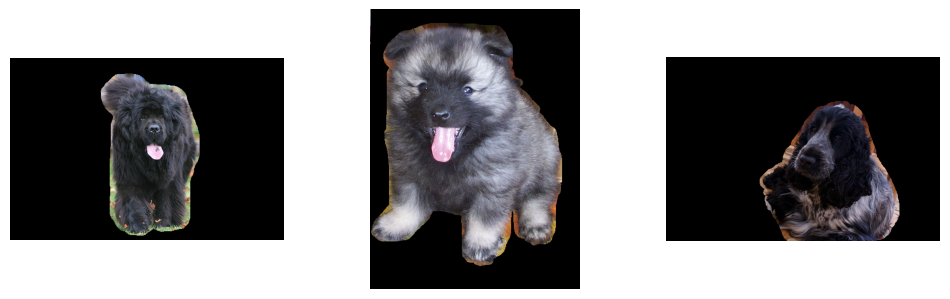

In [ ]:
random_state = np.random.RandomState(seed=42)

dataset = PetDataset(data_root, train=True)

random_ids = random_state.choice(list(range(len(dataset))), size=(3,), replace=False)

images, gt_masks = [], []
for id in random_ids:
    image, mask = dataset[id]
    images.append(image)
    gt_masks.append(mask)

plot_images([image * (mask[..., None] > 0) for image, mask in zip(images, gt_masks)], n_cols=3)

Видим, что сегментационные маски неидеальны и захватывают не только само животное, но и часть бэкграунда.

Вспомним практику и «расчехлим» SAM. Возможно, с помощью него удастся улучшить разметку?

Начнём с инстанцирования SAM'а, возьмём вариант полегче с ViT-L-бэкбоном. Скачайте веса отсюда: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth.

In [ ]:
sam_checkpoint = "sam_vit_l_0b3195.pth"
model_type = "vit_l"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)

Теперь напишем функцию, которая получает на вход предиктор, картинку и (опционально) точку на картинке, а на выходе отдаёт готовую сегментационную маску.

In [ ]:
def segment_with_sam(predictor: SamPredictor, image: np.ndarray, input_point: Optional[tuple[int, int]] = None) -> np.ndarray:
    return ...

Код загрузите в LMS на проверку. Теперь посмотрим, как работает SAM на нашем датасете — сначала попробуем без подсказок, просто автосегментацию.

In [ ]:
auto_sam_mask = segment_with_sam(predictor, images[0])

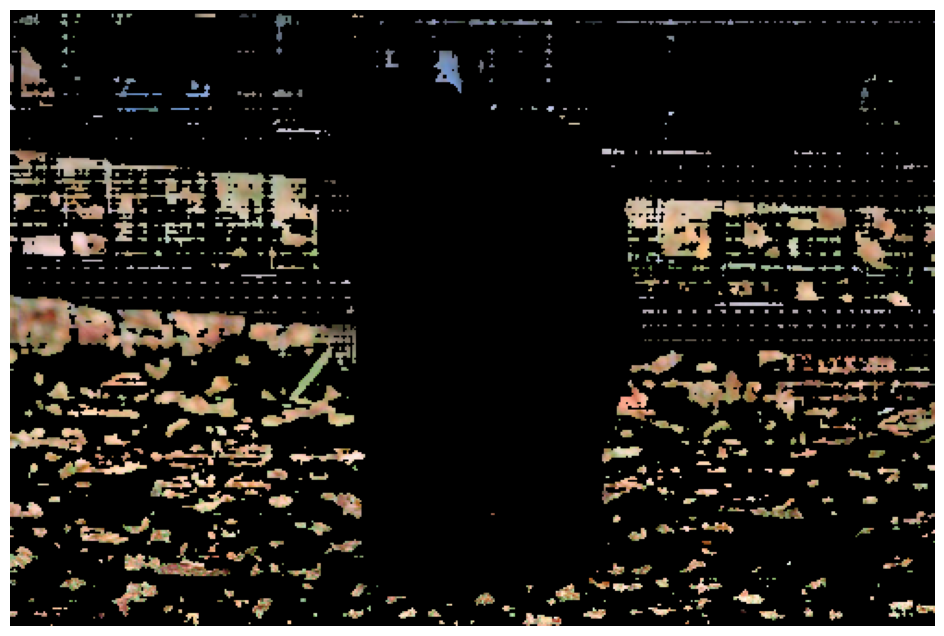

In [ ]:
plot_images([auto_sam_mask[0][..., None] * images[0]], n_cols=1)

Получилось так себе. Попробуем теперь передать туда дополнительную информацию в виде точки на животном. Чтобы не заниматься этим вручную для всех семплов, воспользуемся любезно предоставленными XML-файлами с разметкой — в частности, там есть информация о баундинг-боксах голов животных, попробуем взять их середину.

Примечание: если вам так повезло и для рандомно выбранного семпла не оказалось XML-файла, то возьмите любой другой подходящий ID и позапускайте ячейки.

In [ ]:
# Достанем название нашей картинки
image_name = dataset.image_names[random_ids[0]]

# Загрузим bbox головы животного из xml
path = os.path.join(data_root, "annotations", "xmls", f"{image_name}.xml")
tree = ET.parse(path)

root = tree.getroot()
bbox = [0, 0, 0, 0] # xmin, ymin, xmax, ymax
for i in range(4):
    bbox[i] = int(root[-1][-2][i].text) # root[-1][-2] соответствует annotations -> object -> bndbox

# Возьмём точку как середину баундинг-бокса
mean_point = ((bbox[2] + bbox[0]) // 2, (bbox[3] + bbox[1]) // 2)

In [ ]:
point_sam_mask = segment_with_sam(predictor, images[0], mean_point)

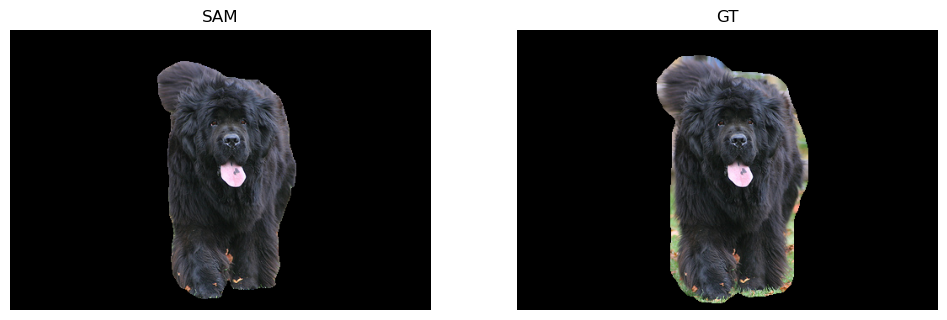

In [ ]:
plot_images(np.stack([point_sam_mask[0][..., None] * images[0], (gt_masks[0][..., None] > 0) * images[0]], axis=0), titles=["SAM", "GT"], n_cols=2)

Как видно, стало значительно лучше! Поэтому предлагаем воспользоваться SAM и улучшить остальные маски.

Хотя SAM так хорошо отработал на представленном кейсе, нельзя исключать вероятности, что на каких-то семплах он может выдать плохой результат. Глазами отсмотреть все кейсы нереально, поэтому предлагаем реализовать механизм фильтрации через IoU, где будем считать его для пары маска с SAM и GT и отсекать по порогу, в случае если будет совсем мусор.

План работ следующий:
1. Реализуйте функцию для подсчёта метрики IoU между двумя сегментационными картами. Код функции загрузите в LMS на проверку.
2. Реализуйте функцию для генерации сегментационных карт SAM'ом: функция должна принимать на вход предиктор, датасет и путь к выходной папке (функция должна её создать, если потребуется), куда она будет записывать улучшенные мапы. Функция должна вернуть True, если всё отработает корректно. Используйте подход, описанный выше, для получения точки для подачи в SAM, не забывайте отфильтровывать полученные маски подсчётом IoU-метрики и выставлением порога (~0.7 должно быть достаточно), если сгенерированная сегмапа не проходит по метрике, то сохраняйте оригинальную маску (т. е. mask из датасета). Код функции загрузите в LMS на проверку.

Примечание: не забудьте умножать маску на 2 для собак, по умолчанию маска будет бинарной.

**Внимание**: не для всех семплов есть соответствующие XML-файлы, поэтому в случае если их нет, просто сохраняйте GT-маску.

**Внимание 2**: не забудьте, что по требованиям класса датасета папка с новыми сегмапами должна лежать внутри data_root/annotations.

In [ ]:
def calculate_iou(pred_mask: np.ndarray, true_mask: np.ndarray) -> float:
    return ...

In [ ]:
def generate_refined_segmaps(predictor: SamPredictor, dataset: torch.utils.data.Dataset, xml_dir: str, output_dir: str) -> bool:
    ...
    return True

In [ ]:
dataset = PetDataset(data_root)

generate_refined_segmaps(predictor, dataset, os.path.join(data_root, "annotations", "xmls"), output_dir=...) # укажите выходную папку

100%|██████████| 3680/3680 [37:32<00:00,  1.63it/s]


True

Отлично! Не забудьте теперь прописывать нужную папку при инициализации датасета. Теперь можем перейти к сегментационной модели.

## Часть 3: Сегментационная модель

В этой части вернёмся к UNet из базового курса DL. Теперь добавим пикантности архитектуре и сначала реализуем её в общем виде, чтобы была возможность гибко заменять различные строительные части UNet — это нам пригодится, когда мы будем усложнять базовую архитектуру.

Приведём примеры базовых блоков для UNet. Ориентируйтесь на их сигнатуру при построении скелета вашего UNet.

In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

class BasicBottleneck(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

class BasicDown(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

class BasicUp(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

class BasicSkip(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(2 * channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU()
        )

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        return self.block(torch.cat([x, skip], dim=1))

Реализуйте общий класс для UNet-подобных сетей с конфигурируемыми блоками. Сигнатура приведена в шаблоне ниже, можете ожидать следующее:
1. Сигнатуры не-базовых блоков будут идентичны базовым, за исключением возможных дополнительных параметров при инициализации блока, их хэндлите через dict `block_kwargs`.
2. У основных `conv_block`-слоёв количество входных каналов всегда равно количеству выходных каналов и они никак не меняют пространственный размер тензора на выходе, каналы и размеры могут меняться только при down/up sampling.

Код UNet загрузите в LMS.

In [ ]:
class UNet(nn.Module):
    def __init__(self,
                 in_channels: int,
                 out_channels: int,
                 filters: list[int],
                 conv_block: Optional[nn.Module] = None,
                 bottleneck_block: Optional[nn.Module] = None,
                 downsampling_block: Optional[nn.Module] = None,
                 upsampling_block: Optional[nn.Module] = None,
                 skip_block: Optional[nn.Module] = None,
                 block_kwargs: dict[str, dict[str, Any]] = {}):
        super().__init__()

        self.n_blocks = len(filters)
        self.blocks = {
            'conv': conv_block or BasicBlock,
            'bottleneck': bottleneck_block or BasicBottleneck,
            'down': downsampling_block or BasicDown,
            'up': upsampling_block or BasicUp,
            'skip': skip_block or BasicSkip
        }
        self.kwargs = {
            'conv': block_kwargs.get('conv', {}),
            'bottleneck': block_kwargs.get('bottleneck', {}),
            'down': block_kwargs.get('down', {}),
            'up': block_kwargs.get('up', {}),
            'skip': block_kwargs.get('skip', {})
        }

        self.conv2d_in = nn.Conv2d(in_channels, filters[0], 3, padding=1)

        # Encoder
        self.encoder_blocks = ...

        self.downsampling_blocks = ...

        # Bottleneck
        self.bottleneck = ...

        # Decoder
        self.upsampling_blocks = ...

        self.skip_blocks = ...

        self.decoder_blocks = ...

        self.conv2d_out = nn.Conv2d(filters[0], out_channels, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return ...

In [ ]:
test_tensor = torch.randn(1,3,512,512)
model = UNet(3, 1, [16, 32, 64, 128])

assert model(test_tensor).size() == torch.Size([1, 1, 512, 512]), "Incorrect output size, check the implementation for potential errors"

summary(model, input_data=test_tensor, device=torch.device("cpu"))

Layer (type:depth-idx)                        Output Shape              Param #
UNet                                          [1, 1, 512, 512]          --
├─Conv2d: 1-1                                 [1, 16, 512, 512]         448
├─ModuleList: 1-6                             --                        (recursive)
│    └─BasicBlock: 2-1                        [1, 16, 512, 512]         --
│    │    └─Sequential: 3-1                   [1, 16, 512, 512]         4,704
├─ModuleList: 1-7                             --                        (recursive)
│    └─BasicDown: 2-2                         [1, 32, 256, 256]         --
│    │    └─Sequential: 3-2                   [1, 32, 256, 256]         4,704
├─ModuleList: 1-6                             --                        (recursive)
│    └─BasicBlock: 2-3                        [1, 32, 256, 256]         --
│    │    └─Sequential: 3-3                   [1, 32, 256, 256]         18,624
├─ModuleList: 1-7                             --         

Отлично, скелет UNet-подобных сетей у нас теперь есть, начнём модифицировать архитектуру — заменим `BasicBlock` на `MBConv`, который был ещё во втором домашнем задании. Можете взять оттуда, только не забудьте адаптировать его под наши ограничения, также учтите, что если не указано обратное, то по умолчанию exp_channels принимает значение 4 * in_channels.

In [ ]:
...

In [ ]:
test_tensor = torch.randn(1, 3, 512, 512)
model = UNet(3, 1, [16, 32, 64, 128], MBConv)

assert model(test_tensor).size() == torch.Size([1, 1, 512, 512]), "Incorrect output size, check the implementation for potential errors"


summary(model, input_data=test_tensor, device=torch.device("cpu"))

Layer (type:depth-idx)                                  Output Shape              Param #
UNet                                                    [1, 1, 512, 512]          --
├─Conv2d: 1-1                                           [1, 16, 512, 512]         448
├─ModuleList: 1-6                                       --                        (recursive)
│    └─MBConv: 2-1                                      [1, 16, 512, 512]         --
│    │    └─Sequential: 3-1                             [1, 16, 512, 512]         3,636
├─ModuleList: 1-7                                       --                        (recursive)
│    └─BasicDown: 2-2                                   [1, 32, 256, 256]         --
│    │    └─Sequential: 3-2                             [1, 32, 256, 256]         4,704
├─ModuleList: 1-6                                       --                        (recursive)
│    └─MBConv: 2-3                                      [1, 32, 256, 256]         --
│    │    └─Sequential: 3-

Теперь займёмся скипами, добавим туда немного «внимания» посредством CBAM: https://arxiv.org/pdf/1807.06521.

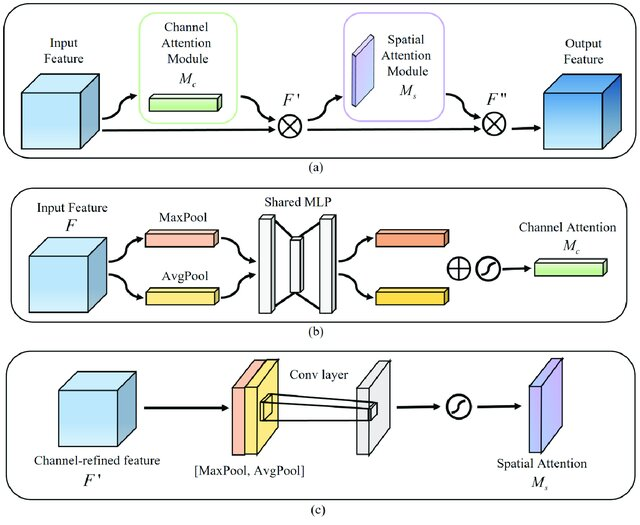

На изображении: a) CBAM; b) Channel Attention; c) Spatial Attention. На выходах последних двух модулей изображён знак сигмоиды. Вам предлагается имплементировать все три модуля.

Этот модуль фактически позволяет модели адаптивно взвешивать все дименшены входного тензора — каналы через Channel Attention, пространственные координаты через Spatial Attention. Такой подход как раз может помочь на задачах вроде сегментации, где модели нужно выделить т. н. region of interest.

**Примечание**: заметьте, что в Spatial Attention используются **пулинги по каналам**, а не по пространству.

In [ ]:
class ChannelAttention(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        mid_channels = max(channels // reduction, 8)
        ...

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return ...

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        ...

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return ...

class CBAMSkip(nn.Module):
    def __init__(self, channels: int, reduction: int = 16, spatial_kernel: int = 7):
        super().__init__()
        ...

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = torch.cat([x, skip], dim=1)
        return ...

In [ ]:
test_tensor = torch.randn(1, 3, 512, 512)
model = UNet(3, 1, [16, 32, 64, 128], MBConv, skip_block=CBAMSkip)

assert model(test_tensor).size() == torch.Size([1, 1, 512, 512]), "Incorrect output size, check the implementation for potential errors"

summary(model, input_data=test_tensor, device=torch.device("cpu"))

Layer (type:depth-idx)                                  Output Shape              Param #
UNet                                                    [1, 1, 512, 512]          --
├─Conv2d: 1-1                                           [1, 16, 512, 512]         448
├─ModuleList: 1-6                                       --                        (recursive)
│    └─MBConv: 2-1                                      [1, 16, 512, 512]         --
│    │    └─Sequential: 3-1                             [1, 16, 512, 512]         3,636
├─ModuleList: 1-7                                       --                        (recursive)
│    └─BasicDown: 2-2                                   [1, 32, 256, 256]         --
│    │    └─Sequential: 3-2                             [1, 32, 256, 256]         4,704
├─ModuleList: 1-6                                       --                        (recursive)
│    └─MBConv: 2-3                                      [1, 32, 256, 256]         --
│    │    └─Sequential: 3-

Напоследок навестим bottleneck-блок, тут используем стак из двух ResBlock + добавим CBAM с одним входом в конце (просто переиспользуйте CA и SA, не создавайте новый класс), считайте, что kernel_size = 3.

Использовать будем классический ResBlock с «ванильной» компоновкой:

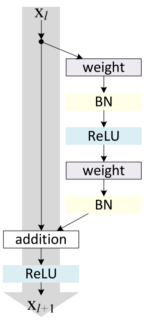

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()

        self.conv_block = ...
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.relu(x + self.conv_block(x))

class ResBottleneck(nn.Module):
    def __init__(self, channels: int, reduction: int = 16, spatial_kernel: int = 7):
        super().__init__()

        ...
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        ...
        return self.relu(x + residual)

In [ ]:
test_tensor = torch.randn(1, 3, 512, 512)
model = UNet(3, 1, [32, 64, 128, 256], MBConv, ResBottleneck, skip_block=CBAMSkip)

assert model(test_tensor).size() == torch.Size([1, 1, 512, 512]), "Incorrect output size, check the implementation for potential errors"

summary(model, input_data=test_tensor, device=torch.device("cpu"))

Layer (type:depth-idx)                                  Output Shape              Param #
UNet                                                    [1, 1, 512, 512]          --
├─Conv2d: 1-1                                           [1, 32, 512, 512]         896
├─ModuleList: 1-6                                       --                        (recursive)
│    └─MBConv: 2-1                                      [1, 32, 512, 512]         --
│    │    └─Sequential: 3-1                             [1, 32, 512, 512]         12,392
├─ModuleList: 1-7                                       --                        (recursive)
│    └─BasicDown: 2-2                                   [1, 64, 256, 256]         --
│    │    └─Sequential: 3-2                             [1, 64, 256, 256]         18,624
├─ModuleList: 1-6                                       --                        (recursive)
│    └─MBConv: 2-3                                      [1, 64, 256, 256]         --
│    │    └─Sequential: 

Отлично! Осталось проверить полученную сетку в деле.

## Часть 4: Тренировка сети

Адаптируйте тренировочный код из практики.

In [ ]:
...

Теперь натренируйте модель, код модели вместе со всеми необходимыми слоями и импортами (включая torch) упакуйте в файл solution.py и загрузите в LMS вместе с весами.

In [ ]:
data_root = ...

# Set random seed for reproducibility
def seed_all(seed: int) -> None:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    random.seed(seed)
    np.random.seed(seed)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define hyperparameters
batch_size = ...
num_epochs = 10
learning_rate = ...

# Create datasets and dataloaders, use albumentations for transforms
train_transform = ...

val_transform = ...


train_dataset = PetDataset(data_root, mask_folder='refined_segmaps', train=True, transform=train_transform)
val_dataset = PetDataset(data_root, mask_folder='trimaps', train=False, transform=train_transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

# Initialize model
model = ...

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
...

Epoch 1/10


  0%|          | 0/460 [00:00<?, ?it/s]

100%|██████████| 459/459 [01:03<00:00,  7.26it/s]


Train Loss: 0.7276, Train IoU: 0.5034
Val Loss: 0.6847, Val IoU: 0.5817
------------------------------------------------------------
Epoch 2/10


100%|██████████| 459/459 [00:44<00:00, 10.25it/s]


...

Train Loss: 0.4542, Train IoU: 0.7259
Val Loss: 0.4354, Val IoU: 0.7458
------------------------------------------------------------
Epoch 9/10


100%|██████████| 459/459 [00:44<00:00, 10.24it/s]


Train Loss: 0.4289, Train IoU: 0.7348
Val Loss: 0.4305, Val IoU: 0.7270
------------------------------------------------------------
Epoch 10/10


100%|██████████| 459/459 [00:44<00:00, 10.29it/s]

Train Loss: 0.4148, Train IoU: 0.7365
Val Loss: 0.4464, Val IoU: 0.7256
------------------------------------------------------------


In [ ]:
torch.save(model.state_dict(), "model.pth")

Отлично! В этом домашнем задании поработали с новым датасетом Oxford Pet Dataset, нашли практическое применение мощным zero-shot-способностям SAM'а и научились модифицировать стандартные архитектуры различными новшествами из других статей.